## Imports:

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("hw2_dataset.csv")
df

,ID,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,...,D_1014,D_1015,D_1016,D_1017,D_1018,D_1019,D_1020,D_1021,D_1022,D_1023
0,AAEAMMIUQZAASJ-MRXNPFEDSA-N,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
1,AAEFNWQXBPYXAC-UHFFFAOYSA-N,1,1,1,1,0,1,1,1,0,...,1,0,1,1,1,0,0,1,1,1
2,AAMHSIWFDKXUMZ-UHFFFAOYSA-N,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,0,0,1,1
3,AAPQXEOSVSLLMB-UHFFFAOYSA-N,1,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,AARXXEHXOBTROW-UHFFFAOYSA-N,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964,ZSRJHGJCRGZJNH-UHFFFAOYSA-N,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
965,ZTCGLAMYEAGAAN-UHFFFAOYSA-N,1,1,1,1,1,1,1,0,0,...,1,1,1,1,1,0,0,1,1,1
966,ZVWRFVCNQOECJS-UHFFFAOYSA-N,1,0,1,1,1,1,0,1,0,...,1,0,1,0,0,0,0,0,0,1
967,ZXAGZULZCKUUKQ-UHFFFAOYSA-N,1,1,1,1,1,1,1,0,0,...,1,1,1,1,1,0,0,1,1,1


In [74]:
unique_counts = {}
for column in df.columns:
    if df[column].nunique() >=3:
        unique_counts[column] = 1

print(unique_counts)
print(df.isna().sum())

{}
D_0       0
D_1       0
D_2       0
D_3       0
D_4       0
         ..
D_1019    0
D_1020    0
D_1021    0
D_1022    0
D_1023    0
Length: 1024, dtype: int64


## Finding the number of clusters

C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

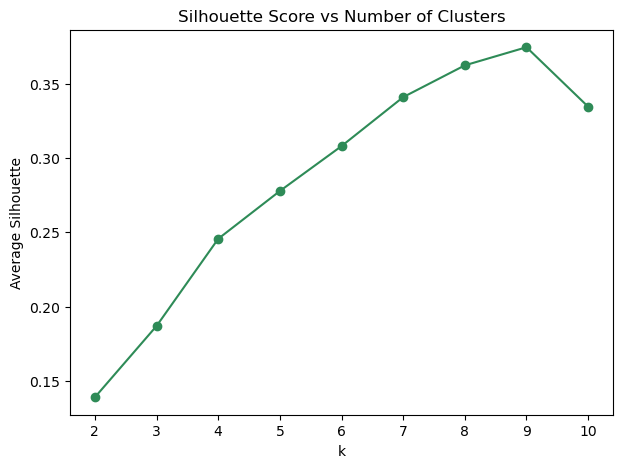

In [6]:
df = df.drop(columns=["ID"])
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)   # df should be a pandas DataFrame

# store silhouette scores
ss = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, n_init=20, random_state=0)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    ss.append(score)

# create results dataframe
df_plot = pd.DataFrame({"k": K, "ss": ss})

# plot
plt.figure(figsize=(7, 5))
plt.plot(df_plot["k"], df_plot["ss"], marker="o", color="seagreen")
plt.xlabel("k")
plt.ylabel("Average Silhouette")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()


## Clustering with K-Means

C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


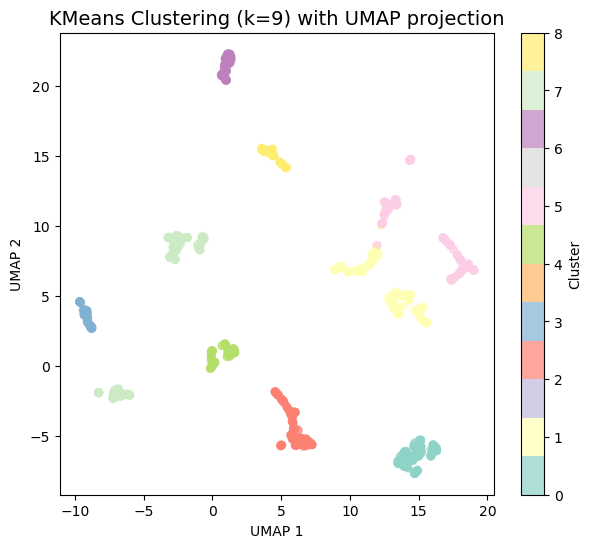

In [46]:
kmeans = KMeans(n_clusters=9, n_init="auto", random_state=0)
labels = kmeans.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"KMeans Clustering (k=9) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


## Trying other models (HDBSCAN and Agglomeritive clustering) with the same number of clusters

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


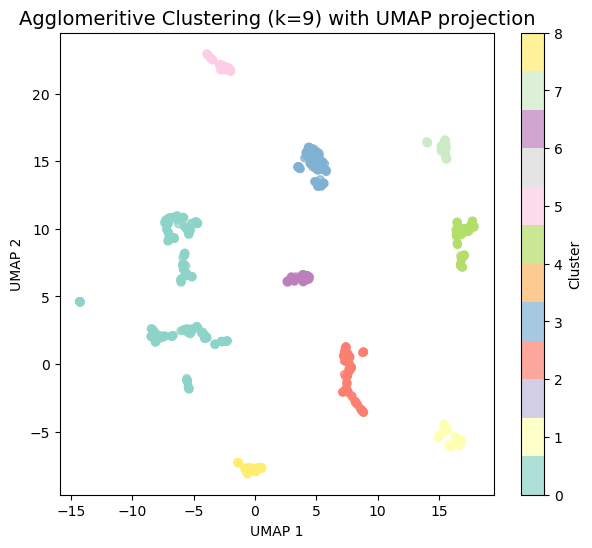

In [48]:
agg = AgglomerativeClustering(n_clusters=9, linkage="ward")
labels = agg.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"Agglomeritive Clustering (k=9) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


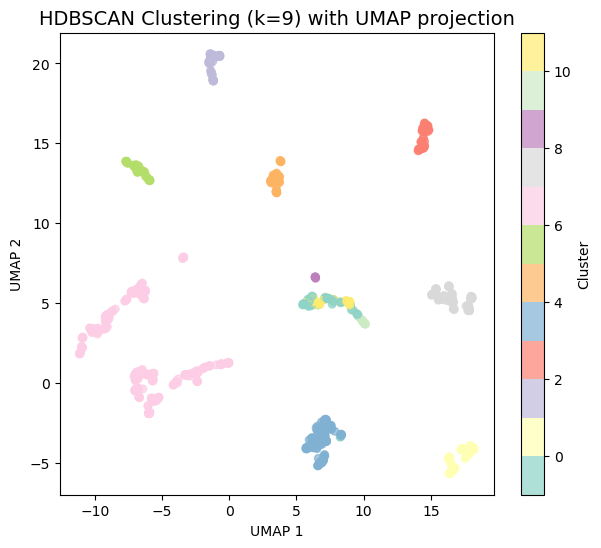

In [52]:
dbscan = HDBSCAN(cluster_selection_epsilon = 0.1)
labels = dbscan.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"HDBSCAN Clustering (k=9) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Comparing HDBSCAN and Agglomeritive clustering results with distance as cosine

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


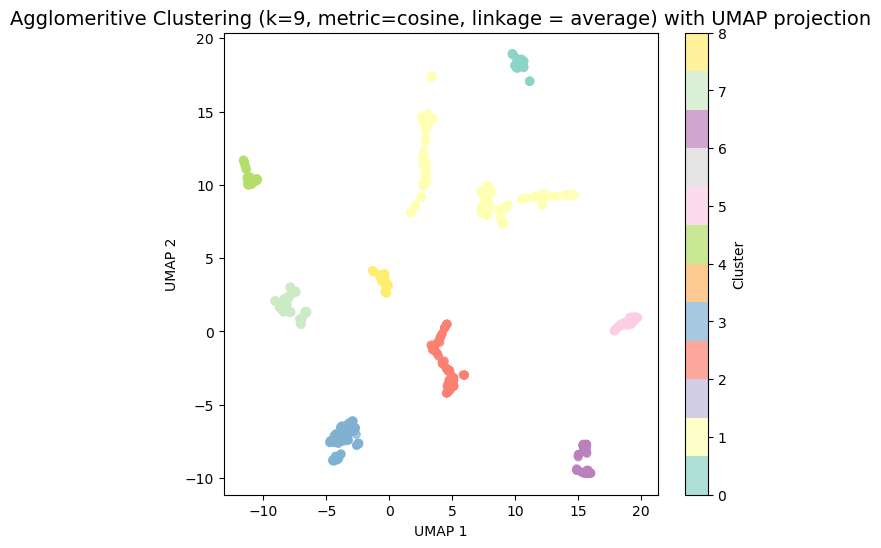

In [53]:
agg = AgglomerativeClustering(n_clusters=9, metric="cosine", linkage = "average")
labels = agg.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"Agglomeritive Clustering (k=9, metric=cosine, linkage = average) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


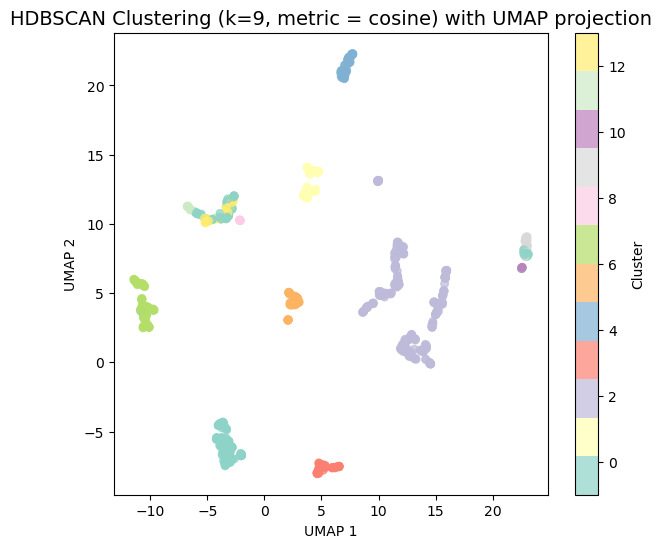

In [56]:
dbscan = HDBSCAN(cluster_selection_epsilon = 0.1, metric = "cosine")
labels = dbscan.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"HDBSCAN Clustering (k=9, metric = cosine) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Comparing HDBSCAN and Agglomeritive clustering results with distance as Manhattan

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


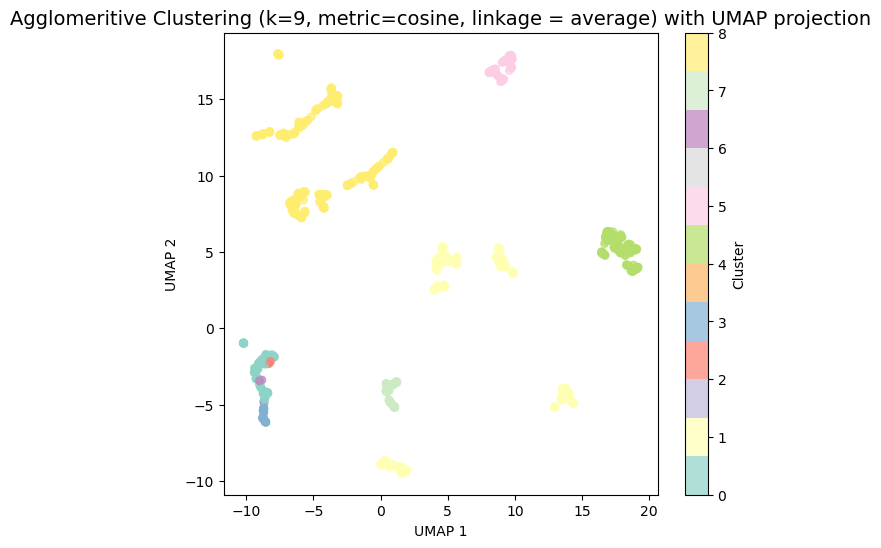

In [58]:
agg = AgglomerativeClustering(n_clusters=9, metric="manhattan", linkage = "average")
labels = agg.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"Agglomeritive Clustering (k=9, metric=cosine, linkage = average) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

C:\Users\Trish\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


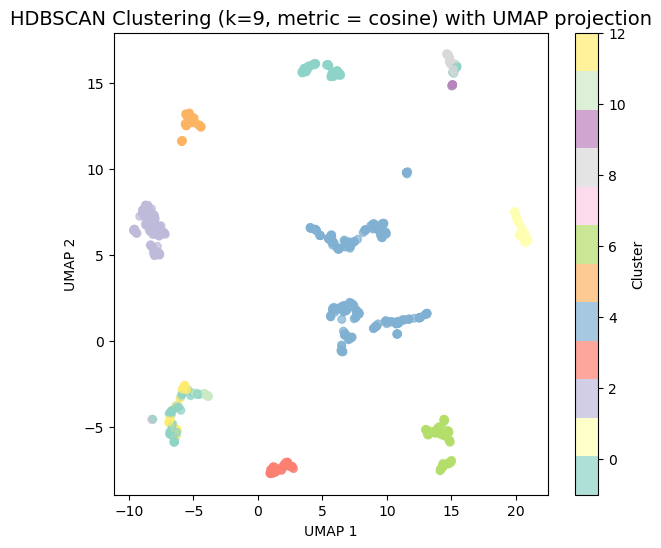

In [59]:
dbscan = HDBSCAN(cluster_selection_epsilon = 0.1, metric = "manhattan")
labels = dbscan.fit_predict(df_scaled)

# UMAP dimensionality reduction
reducer = umap.UMAP(n_neighbors=9, min_dist=0.1, random_state=0)
X_umap = reducer.fit_transform(df_scaled, force_all_finite=False)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=labels, cmap="Set3", s=30, alpha=0.7)
plt.title(f"HDBSCAN Clustering (k=9, metric = cosine) with UMAP projection", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Write up

Given the dataset, I performed various clustering methods.Examining the data, there does not appear to be any NA values to take care of. Firstly, I determined the number of clusters with a sillhouette plot as I feel it is more sophisicated compared to an elbow plot. Based on the plot, It appears the optimal clusters to make with the data is 9. Then i using a kmeans model set to 9 clusters, I visualised that using UMAP to check if clustering works for this data and how well defined are the clusters. Based on the visualization, clustering does indeed work for this dataset and there do appear to be some tight clusters but even tight groups of a single cluster dispersed across the plot. 

Based on the id column of the data and how the features are boolean-like, I could infer that this data may be genes where the make up of each is analyzed via seeing if a certain feature is present or not. Due to the nature of genes, I decided to use agglomerative/heirarchical clustering and HDBSCAN. HDBSCAN is a clustering model that is good at handeling outliers and with heirarchical clustering, we can see which subjects are related and thus are grouped together. When using the euclidean distance and a cluster value of 9, The agglomerative clustering did much better compared to the HDBSCAN as he clusters were well defined and seperate unlike in the HDBSCAN, where in the middle of the dataset, there is a cluster made up of other clusters.

I then experimented with the 2 clustering models by comparing the results if the distance metric was cosine. Most of the clusters seemed to be coded as falling under cluster 8 and there is slight merging in one cluster, it is other wise seems well defined. With the HDBSCAN, the clusters are well defined and there are distinct clusters tha appera but a few clusters are still multicolored. 

Based on the generatted plots of each model, the best model for the data is a simple agglomerative model with 9 clusters as the clusters are more closer together and distinct. The k-means model does work but it is not the best because the clustes are not as dintict and closer together compared to the agglomerative model. 